In [1]:
# Tutorial environment
using Pkg
pkg_dir = dirname(dirname(pathof(NTRsurv)))
Pkg.activate(joinpath(pkg_dir, "examples"))
Pkg.instantiate()

  Activating project at `~/NTRsurv.jl/examples`


In [2]:
## Load packages needed for tutorial
using Random, CSV, DataFrames, Distributions, Survival, StatsModels, NTRsurv, Plots, LaTeXStrings, Printf, PrettyTables
frequentist_confidence_bands_path = joinpath( dirname(dirname(pathof(NTRsurv))), "examples", "frequentist_confidence_bands.jl")
include(frequentist_confidence_bands_path)

[ Info: Precompiling DataFrames [a93c6f00-e57d-5684-b7b6-d8193f3e46c0] (cache misses: wrong dep version loaded (12))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling NTRsurv [44a71bb7-9d27-4d6a-8d2f-9a31f1763d85] (cache misses: wrong dep version loaded (10))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


bootstrap_confidence_band (generic function with 2 methods)

In [ ]:
import Pkg; Pkg.add("PrettyTables")

In [5]:
using CSV
using DataFrames
using PrettyTables
using Printf

In [4]:
# Set random number generator seed for reproducibility
Random.seed!(1234)

TaskLocalRNG()

## Uncertainty quantification with credible and confidence bands for the Cox proportional hazards regression model.

This tutorial shows how to assess uncertainty quantification for survival curves inferred in NTR-Cox regression models.

#### Lung cancer real data

In this example we use data from a clinical study of patients with advanced lung cancer conducted by the North Central Cancer Treatment Group. This dataset is commonly used to illustrate the Cox proportional hazards model and is availiable in R `survival` package. The data was modified so the variable `time` is scaled to years by dividing over 365, `status` variable was set to binary 0-1 variables with 1 denoting an exact observation, covariate columns distinct from `age`, `sex` and `wt_loss` were dopped, rows with NaN values were removed so the dataset consists of 214 observations, `age` covariate was changed of scale by dividing over 100, and covarate `wt_loss` was standardized by substracting its median followed by diving over inter-quantile range.

In [6]:
# Load data
lung_path = joinpath( dirname(dirname(pathof(NTRsurv))), "examples", "data", "lung.csv")
lung = CSV.read(lung_path, DataFrame)
first(lung,7)

Row,time,status,age,sex,wt_loss
,Float64,Int64,Float64,Float64,Float64
1,1.24658,1,0.68,1.0,0.507937
2,2.76712,0,0.56,1.0,0.507937
3,0.575342,1,0.57,1.0,0.253968
4,2.41918,1,0.6,1.0,-0.444444
5,2.8,0,0.74,1.0,-0.444444
6,0.849315,1,0.68,2.0,0.190476
7,0.989041,1,0.71,2.0,-0.380952


In [7]:
# Data size
size(lung)

(214, 5)

In [8]:
# Create status array,
δ = lung[!,:status];

In [9]:
# Number of exact observations
sum(δ)

152

In [10]:
# Create time array.
T = lung[!,:time];

In [11]:
# Create NTRsurv structures
data = SurvivalData(T,δ)
baseline = EmpiricalBayesBaseline(data)
# Set variance modulation hyper-parameter
α = 1.0;

In [12]:
# Plotting time grid
t =  collect(LinRange(0.0,3.0,100));

For the above baseline and $\alpha$ hyper-parameter choices we inspect the implied prior distribution on survival curves.

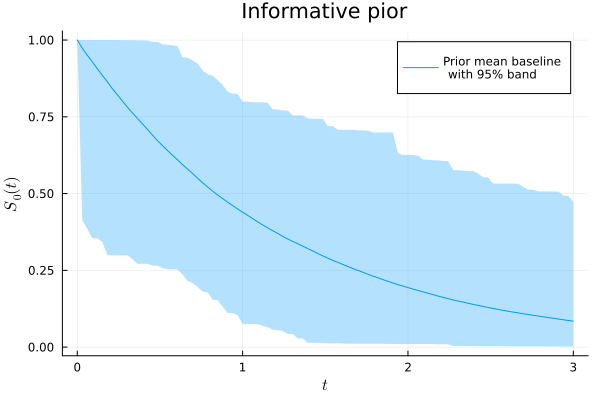

In [13]:
# Prior inspection
prior_band_d, prior_band_m, prior_band_u = prior_credible_band(0.05,3000,t,5.0,baseline)
prior_plot = plot(t, prior_band_m,  ribbon = (prior_band_m .- prior_band_d, prior_band_u .- prior_band_m), fillalpha=0.3, xlabel="\$t\$", ylabel="\$S_0(t)\$", label="Prior mean baseline \n with 95% band",  title="Informative pior", size=(600,400))

# Regression

In [14]:
# Create covariate array.
z_keys = [:age,:sex,:wt_loss]
Z = [ [ lung[j,i] for i in z_keys] for j in 1:nrow(lung)]
first(Z,7)

7-element Vector{Vector{Float64}}:
 [0.68, 1.0, 0.5079365079365079]
 [0.56, 1.0, 0.5079365079365079]
 [0.57, 1.0, 0.25396825396825395]
 [0.6, 1.0, -0.4444444444444444]
 [0.74, 1.0, -0.4444444444444444]
 [0.68, 2.0, 0.19047619047619047]
 [0.71, 2.0, -0.38095238095238093]

In [15]:
# Median quantities for later assesment of fits
med_age = median([v[1] for v in Z])
med_age_m = median([v[1] for v in Z[lung.sex .== 1.0] ])
med_age_f = median([v[1] for v in Z[lung.sex .== 2.0] ])
med_wt_loss_m = median([v[3] for v in Z[lung.sex .== 1.0] ])
med_wt_loss_f = median([v[3] for v in Z[lung.sex .== 2.0] ]);

In [16]:
# Data struct for NTR modelling
dataregre = RegressionSurvivalData( T, δ, Z)

NTRsurv.RegressionSurvivalDataRep([0.0136986301369863, 0.030136986301369864, 0.030136986301369864, 0.03287671232876712, 0.03561643835616438, 0.03561643835616438, 0.0410958904109589, 0.07123287671232877, 0.0821917808219178, 0.08493150684931507  …  2.095890410958904, 2.1671232876712327, 2.208219178082192, 2.23013698630137, 2.249315068493151, 2.3013698630136985, 2.419178082191781, 2.643835616438356, 2.767123287671233, 2.8], [0.0136986301369863, 0.030136986301369864, 0.03287671232876712, 0.03561643835616438, 0.0410958904109589, 0.07123287671232877, 0.0821917808219178, 0.08493150684931507, 0.14520547945205478, 0.14794520547945206  …  2.095890410958904, 2.1671232876712327, 2.208219178082192, 2.23013698630137, 2.249315068493151, 2.3013698630136985, 2.419178082191781, 2.643835616438356, 2.767123287671233, 2.8], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  1, 1, 0, 1, 0, 0, 1, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  1, 1, 0, 1, 0, 0, 1, 0, 0, 0], [[0.65, 2.0, -0.12698412698412698], [0.74, 1.0, -0.4444

In [17]:
# Compilation runs
NTRsurv.loglikelihood([0.3,0.0,-0.3],α,baseline,dataregre) # In this notebbok loglikelihood funcion is also loaded by Survival so it has to be sepcified.
robbins_monro_mh_within_gibbs_tune(3,3,x->NTRsurv.loglikelihood(x,α,baseline,dataregre),[1.0,1.0,1.0],[1.0,1.0,1.0],[0.4,0.4,0.4],0.7)

([[1.0, 1.0, 1.0], [1.0634913484723583, 1.0634913484723583, 1.0634913484723583], [1.113940274312152, 0.8835317934793192, 0.8835317934793192], [1.3983053111119192, 0.7592686142773132, 0.9176537961413386]], [0.07398730804021936, 0.09792179747747298, 0.10364619448679838], -672.1011862612232)

In [18]:
#  Robbins-Monro algorithm for variance of proposal distribution tuning
sd_prop_tuned, s₀_tune, lliks₀_tune = robbins_monro_mh_within_gibbs_tune(150,100,x->NTRsurv.loglikelihood(x,α,baseline,dataregre) + logpdf(Normal(0,5),x[1]) + logpdf(Normal(0,5),x[2]) + logpdf(Normal(0,5),x[3]),[1.0,1.0,1.0],[1.0,1.0,1.0],[0.4,0.4,0.4],0.7; show_progress=false)

([[1.0, 1.0, 1.0], [1.1494470310131113, 0.8797752848920806, 0.8635163340914853], [1.2646336335702275, 0.813995249091458, 0.7588506083346901], [1.3210365945244482, 0.7551634490151008, 0.6880208987954454], [1.3712749668738677, 0.7294050814998818, 0.6244724561818908], [1.4293765796986608, 0.6933328161501031, 0.590178233155632], [1.4382788956064105, 0.6763258269568754, 0.5466722391622757], [1.477434633500991, 0.664322854979293, 0.5433335758600838], [1.4883738218422764, 0.6506288529226217, 0.5241127412943085], [1.5198998744334786, 0.6420316570136608, 0.5058476243440387]  …  [1.884405359574196, 0.46935391504625434, 0.2782280008285561], [1.8852314491114854, 0.4694126933715133, 0.2783499709977119], [1.8842919692292632, 0.4688865248348525, 0.2780379662330612], [1.8915498888647762, 0.4696721806128953, 0.27807244869199255], [1.8888671075275356, 0.4698751051116381, 0.27733556634958867], [1.8879393011067407, 0.4692118566585267, 0.277114232299823], [1.8899020927840153, 0.46955614404253987, 0.2769787

In [19]:
# Metropolis-Hastings within Gibbs chain run
chain_s, _ =  random_walk_mh_within_gibbs( 3000, x-> NTRsurv.loglikelihood(x,α,baseline,dataregre) + logpdf(Normal(0,5),x[1]) + logpdf(Normal(0,5),x[2]) + logpdf(Normal(0,5),x[3]), s₀_tune, lliks₀_tune, sd_prop_tuned[end])

([[1.0840939744168328, -0.3093720956520127, -0.05666813861094706], [1.3089008473023696, -0.3093720956520127, -0.05666813861094706], [0.06941042691136978, -0.5747056928082139, -0.10583533109667576], [0.06941042691136978, -0.5602843989559864, -0.10583533109667576], [-0.0518411499666451, -0.310715066273879, -0.08892017100800265], [-0.0518411499666451, -0.310715066273879, -0.08892017100800265], [1.2623379673287694, -0.310715066273879, -0.08892017100800265], [1.2623379673287694, -0.41024904373910587, -0.08892017100800265], [0.6166021702391109, -0.41024904373910587, -0.08892017100800265], [0.6166021702391109, -0.6703440048482924, -0.08892017100800265]  …  [1.6003660443748902, -0.6282103346974411, -0.016802636767421927], [1.6003660443748902, -0.6282103346974411, -0.016802636767421927], [1.6003660443748902, -0.817332882821517, 0.022549715356419323], [1.6003660443748902, -0.817332882821517, 0.022549715356419323], [1.6003660443748902, -0.817332882821517, 0.022549715356419323], [1.600366044374890

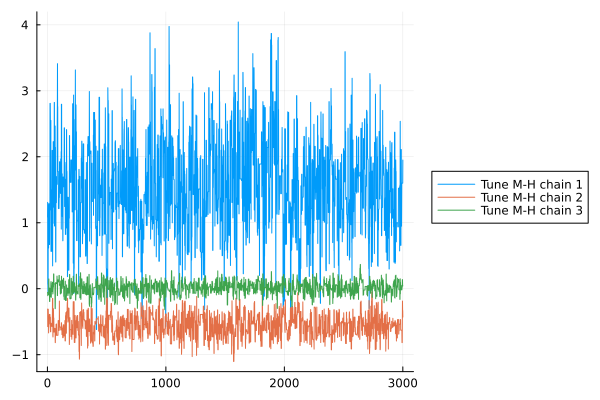

In [20]:
# Plot MH within Gibbs chains
plot([ v[1] for v in chain_s],label="Tune M-H chain 1",legend=:outerright)
plot!([ v[2] for v in chain_s],label="Tune M-H chain 2")
plot!([ v[3] for v in chain_s],label="Tune M-H chain 3")

In [21]:
# Acceptance rates in the MH within Gibbs chains, target values were 0.4
acceptance_rate(chain_s)

3-element Vector{Float64}:
 0.40346782260753583
 0.3901300433477826
 0.39813271090363456

In [22]:
# Posterior mean estimate of regression coefficients
c_post = mean(chain_s)

3-element Vector{Float64}:
  1.5526352284851233
 -0.5577682842427224
  0.013013495922569902

In [23]:
# NTR model for Cox regression
cox_model = CoxNeutralToTheRightModel( c_post, α, baseline, dataregre)

NTRsurv.CoxNeutralToTheRightModelRep([1.5526352284851233, -0.5577682842427224, 0.013013495922569902], 1.0, 1.4426950408889634, Baseline(NTRsurv.var"#ExponentialBaseline##0#ExponentialBaseline##1"{Float64}(0.825546098446521), NTRsurv.var"#ExponentialBaseline##2#ExponentialBaseline##3"{Float64}(0.825546098446521), NTRsurv.var"#ExponentialBaseline##4#ExponentialBaseline##5"{Float64}(0.825546098446521)), NTRsurv.cox_rs, NTRsurv.RegressionSurvivalDataRep([0.0136986301369863, 0.030136986301369864, 0.030136986301369864, 0.03287671232876712, 0.03561643835616438, 0.03561643835616438, 0.0410958904109589, 0.07123287671232877, 0.0821917808219178, 0.08493150684931507  …  2.095890410958904, 2.1671232876712327, 2.208219178082192, 2.23013698630137, 2.249315068493151, 2.3013698630136985, 2.419178082191781, 2.643835616438356, 2.767123287671233, 2.8], [0.0136986301369863, 0.030136986301369864, 0.03287671232876712, 0.03561643835616438, 0.0410958904109589, 0.07123287671232877, 0.0821917808219178, 0.0849315

In [24]:
# We will compute posterior survival bands for covariates
z_new_1 = [med_age_m,1.0,med_wt_loss_m]
z_new_2 = [med_age_f,2.0,med_wt_loss_f]
zv = [z_new_1,z_new_2]

2-element Vector{Vector{Float64}}:
 [0.64, 1.0, 0.06349206349206349]
 [0.61, 2.0, -0.19047619047619047]

In [25]:
# NTR posterior credible bands computation
NTR_bands = posterior_credible_band(0.05,3000,t, zv, cox_model)

2-element Vector{Tuple{Vector{Float64}, Vector{Float64}, Vector{Float64}}}:
 ([1.0, 0.9326289831353572, 0.9056983201475424, 0.8712806438657924, 0.8692549353863226, 0.850235802599824, 0.8072831366169773, 0.7919039419511071, 0.7879996741537144, 0.7526738121819576  …  0.0008445285775922554, 0.0008433440229196025, 0.0008433440229196025, 0.00010187175206095671, 0.00010187175206095671, 0.00010187175206095671, 1.8655672557553588e-5, 1.8549116650092517e-5, 6.172052966685424e-6, 6.129830709513853e-6], [1.0, 0.982940188455939, 0.9601922796170566, 0.9431539326863693, 0.9429680953409795, 0.925694760237546, 0.891150450690728, 0.8852172971947686, 0.8680234849460915, 0.8452239194073045  …  0.026614244964561447, 0.026280000521181596, 0.02589079280659635, 0.02524687562606693, 0.024417171962917456, 0.023667234462124834, 0.022854245111313076, 0.022225356101638713, 0.021456484542769345, 0.02068470043868327], [1.0, 0.999678498045843, 0.9915279505226929, 0.9848740042531834, 0.9848287590112745, 0.97813887200

In [26]:
# Fully Bayes Cox-NTR model fit
fully_bayes_cox_model = CoxNeutralToTheRightFullyBayesianModel(chain_s, α, baseline, dataregre)

CoxNeutralToTheRightFullyBayesianModel([[1.0840939744168328, -0.3093720956520127, -0.05666813861094706], [1.3089008473023696, -0.3093720956520127, -0.05666813861094706], [0.06941042691136978, -0.5747056928082139, -0.10583533109667576], [0.06941042691136978, -0.5602843989559864, -0.10583533109667576], [-0.0518411499666451, -0.310715066273879, -0.08892017100800265], [-0.0518411499666451, -0.310715066273879, -0.08892017100800265], [1.2623379673287694, -0.310715066273879, -0.08892017100800265], [1.2623379673287694, -0.41024904373910587, -0.08892017100800265], [0.6166021702391109, -0.41024904373910587, -0.08892017100800265], [0.6166021702391109, -0.6703440048482924, -0.08892017100800265]  …  [1.6003660443748902, -0.6282103346974411, -0.016802636767421927], [1.6003660443748902, -0.6282103346974411, -0.016802636767421927], [1.6003660443748902, -0.817332882821517, 0.022549715356419323], [1.6003660443748902, -0.817332882821517, 0.022549715356419323], [1.6003660443748902, -0.817332882821517, 0.0

In [27]:
# Fully Bayes NTR posterior credible bands computation
fullyBayesNTR_bands = posterior_credible_band(0.05, t, zv, fully_bayes_cox_model)

2-element Vector{Tuple{Vector{Float64}, Vector{Float64}, Vector{Float64}}}:
 ([1.0, 0.9254840467633284, 0.8874951111878707, 0.8564253938567808, 0.8564253938567808, 0.839770957107095, 0.7969084578577391, 0.7882402121563347, 0.7774668599763259, 0.7517574622921014  …  0.0022886168179418677, 0.002211909365476425, 0.002034183245263906, 0.00011003092001849838, 1.3599506048375196e-5, 1.3599506048375196e-5, 1.036855716230032e-6, 1.036855716230032e-6, 1.036855716230032e-6, 1.0368557162300282e-6], [1.0, 0.9829023006406845, 0.9601157640320938, 0.9430838618496125, 0.9428710012522944, 0.9258761374488302, 0.8917264634808048, 0.8859466966356534, 0.868968170827825, 0.8465682438241905  …  0.027853792791444155, 0.027543116079258554, 0.02714025693735551, 0.02645781916512076, 0.025640068258768026, 0.024839544833767786, 0.02398841773744878, 0.02331273996693258, 0.022554589437360634, 0.02177303977601363], [1.0, 0.999079561906225, 0.9911349411744361, 0.9880324823170112, 0.988032417396302, 0.9743482532050213,

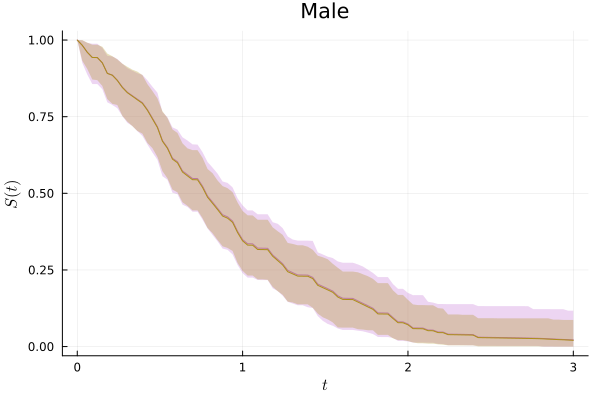

In [28]:
# Plot for fully-Bayes NTR-Cox comparisson with vanilla NTR-Cox survival band fits
fullyComp_plotM =  plot( t, fullyBayesNTR_bands[1][2],  ribbon = ( fullyBayesNTR_bands[1][2] .- fullyBayesNTR_bands[1][1], fullyBayesNTR_bands[1][3] .- NTR_bands[1][2]), c=4, xlabel="\$t\$", ylabel="\$S(t)\$", fillalpha=0.3, label="Fully Bayes NTR posterior 95% credible band",size=(600,400) , title="Male")
plot!( t, NTR_bands[1][2],  ribbon = ( NTR_bands[1][2] .- NTR_bands[1][1], NTR_bands[1][3] .- NTR_bands[1][2]), c=5, fillalpha=0.3,  label="NTR posterior 95% credible band",legend=false)

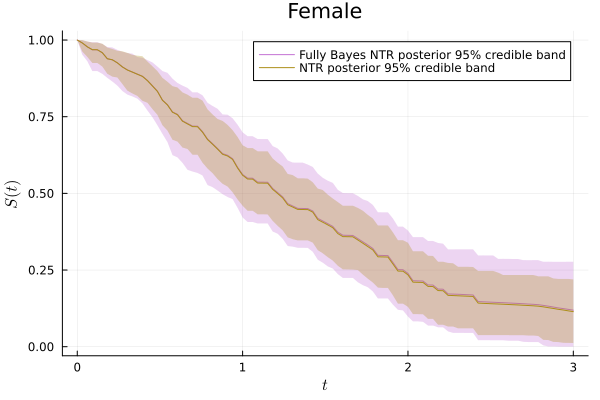

In [29]:
# Plot for fully-Bayes NTR-Cox comparisson with vanilla NTR-Cox survival band fits
fullyComp_plotF = plot( t, fullyBayesNTR_bands[2][2],  ribbon = ( fullyBayesNTR_bands[2][2] .- fullyBayesNTR_bands[2][1], fullyBayesNTR_bands[2][3] .- NTR_bands[2][2]), c=4, xlabel="\$t\$", ylabel="\$S(t)\$", fillalpha=0.3, label="Fully Bayes NTR posterior 95% credible band",size=(600,400),title="Female")
plot!( t, NTR_bands[2][2],  ribbon = ( NTR_bands[2][2] .- NTR_bands[2][1], NTR_bands[2][3] .- NTR_bands[2][2]), c=5, fillalpha=0.3,  label="NTR posterior 95% credible band")

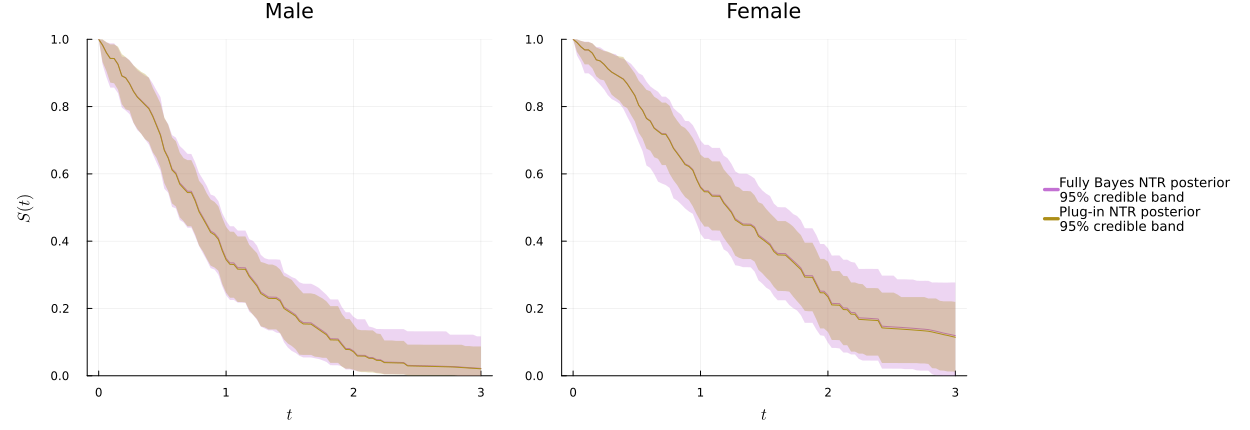

In [30]:
using Measures
# Adjust margins of the two equally sized data panels
plot!(
    fullyComp_plotM,
    left_margin = 9mm,
    right_margin = 2mm,
    bottom_margin = 6mm,
    top_margin = 3mm,
    ylims = (0.0, 1.0)
)
plot!(
    fullyComp_plotF,
    ylabel = "",
    left_margin = 3mm,
    right_margin = 2mm,
    bottom_margin = 6mm,
    top_margin = 13mm,
    ylims = (0.0, 1.0),
    legend = false
)
# Separate panel containing only the shared legend
legend_plot = plot(
    [NaN],
    [NaN],
    color = 4,
    linewidth = 3,
    label = "Fully Bayes NTR posterior \n95% credible band",
    framestyle = :none,
    showaxis = false,
    grid = false,
    legend = :left,
    legendfontsize = 9,
    background_color_legend = :transparent,
    foreground_color_legend = :transparent
)
plot!(
    legend_plot,
    [NaN],
    [NaN],
    color = 5,
    linewidth = 3,
    label = "Plug-in NTR posterior \n95% credible band"
)
# Equal-sized male and female panels plus a separate legend column
bands_layout = @layout [
    a b c{0.2w}
]
bands_plot = plot(
    fullyComp_plotM,
    fullyComp_plotF,
    legend_plot,
    layout = bands_layout,
    size = (1250, 430),
    top_margin = 5mm,
    margin = 1mm,
    link = :y
)
bands_plot

In [31]:
savefig(bands_plot, "lung_cox_uq_FullyBayesVsBayes.png")

"/home/alan/NTRsurv.jl/lung_cox_uq_FullyBayesVsBayes.png"

We observe that there is uncertainty in the regression coefficients as the plug-in Cox-NTR model differs from the fully Bayesian Cox-NTR model, specially in the female median covariate fits.

In [32]:
# DataFrame for frequentist Cox fits with Survival.jl
df = DataFrame( time = dataregre.Tr, status = dataregre.δr, age = [ z[1] for z in Z ], sex = [ z[2] for z in Z ], wt_loss = [ z[3] for z in Z ]  )
first(df,7)

Row,time,status,age,sex,wt_loss
,Float64,Int64,Float64,Float64,Float64
1,0.0136986,1,0.68,1.0,0.507937
2,0.030137,1,0.56,1.0,0.507937
3,0.030137,1,0.57,1.0,0.253968
4,0.0328767,1,0.6,1.0,-0.444444
5,0.0356164,1,0.74,1.0,-0.444444
6,0.0356164,1,0.68,2.0,0.190476
7,0.0410959,1,0.71,2.0,-0.380952


In [33]:
# Add EvenTime column to DataFrame
df.event = EventTime.( df.time, df.status)
last(df.event,7)

7-element Vector{EventTime{Float64}}:
 2.23013698630137
 2.249315068493151+
 2.3013698630136985+
 2.419178082191781
 2.643835616438356+
 2.767123287671233+
 2.8+

In [34]:
# Fit fequentist Cox model
freq_cox_model = Survival.coxph(@formula(event ~ age + sex + wt_loss), df)

StatsModels.TableRegressionModel{CoxModel{Float64}, Matrix{Float64}}

event ~ age + sex + wt_loss

Coefficients:
StatsBase.CoefTable(Any[[0.47544228018481366, -0.22857171306752216, 0.07844848760457304], [0.8793013532870398, 0.1701139182754456, 0.10689536845045351], [0.5407045928082518, -1.3436391059867463, 0.7338810721339557], [0.5887112123319626, 0.17906511735856492, 0.46302122393804684]], ["Estimate", "Std.Error", "z value", "Pr(>|z|)"], ["age", "sex", "wt_loss"], 4, 0)

In [35]:
# Frequentist survival curves estimators
c_freq =  coef(freq_cox_model)
κBreslow, t_Breslow = BreslowEstimCoxModel_with_time(freq_cox_model)
Sfreq1 = exp.( - exp( dot(c_freq,zv[1]) )  .* κBreslow )
Sfreq2 = exp.( - exp( dot(c_freq,zv[2]) )  .* κBreslow );

In [36]:
# Computation of asymptotic frequentist confidence bands
freq_bands = freq_confidence_bands( 0.05, 3000, t, zv, dataregre, freq_cox_model)  

2-element Vector{Tuple{Vector{Float64}, Vector{Float64}, Vector{Float64}}}:
 ([1.0, 0.9554195878331918, 0.916374102839651, 0.8976489011215031, 0.8976489011215031, 0.8677317895441415, 0.835901468747248, 0.830753145785579, 0.8073215568924573, 0.7774272920526195  …  0.009244777743267325, 0.009244777743267325, 0.009244777743267325, 0.009244777743267325, 0.009244777743267325, 0.009244777743267325, 0.009244777743267325, 0.009244777743267325, 0.009244777743267325, 0.009244777743267325], [1.0, 0.9847986311162673, 0.9648120319327917, 0.9500542520180845, 0.9500542520180845, 0.9350664381339764, 0.9049377420373437, 0.8999205004870365, 0.885027362547577, 0.8644688285252766  …  0.047207165001665906, 0.047207165001665906, 0.047207165001665906, 0.047207165001665906, 0.047207165001665906, 0.047207165001665906, 0.047207165001665906, 0.047207165001665906, 0.047207165001665906, 0.047207165001665906], [1.0, 1.0241721408467037, 1.0137996943844967, 1.0026878192871125, 1.0026878192871125, 0.9941772898661527, 

In [37]:
# Computation of bootstrapped frequentist bands
boot_bands = bootstrap_confidence_band( 0.05, 3000, t, zv, df, z_keys)

2-element Vector{Tuple{Vector{Float64}, Vector{Float64}, Vector{Float64}}}:
 ([1.0, 0.9313693162834435, 0.9152574408554087, 0.8787129772260631, 0.8787129772260631, 0.8591004286144912, 0.8180815538600675, 0.8169510440268224, 0.7967092522389926, 0.7653317630361897  …  0.0001572269898555879, 0.0001572269898555879, 0.0001572269898555879, 0.0001572269898555879, 0.0001572269898555879, 0.0001572269898555879, 0.0001572269898555879, 0.0001572269898555879, 0.0001572269898555879, 0.0001572269898555879], [1.0, 0.9849130513696738, 0.9649818805416865, 0.9498648773100243, 0.9498648773100243, 0.9347357140654275, 0.9046754206750309, 0.8997790267121514, 0.8848948140507619, 0.8647775941536657  …  0.04482440792172679, 0.04482440792172679, 0.04482440792172679, 0.04482440792172679, 0.04482440792172679, 0.04482440792172679, 0.04482440792172679, 0.04482440792172679, 0.04482440792172679, 0.04482440792172679], [1.0, 1.0, 1.0, 0.9946572382334047, 0.9946572382334047, 0.986150759976416, 0.9673422245680328, 0.96017

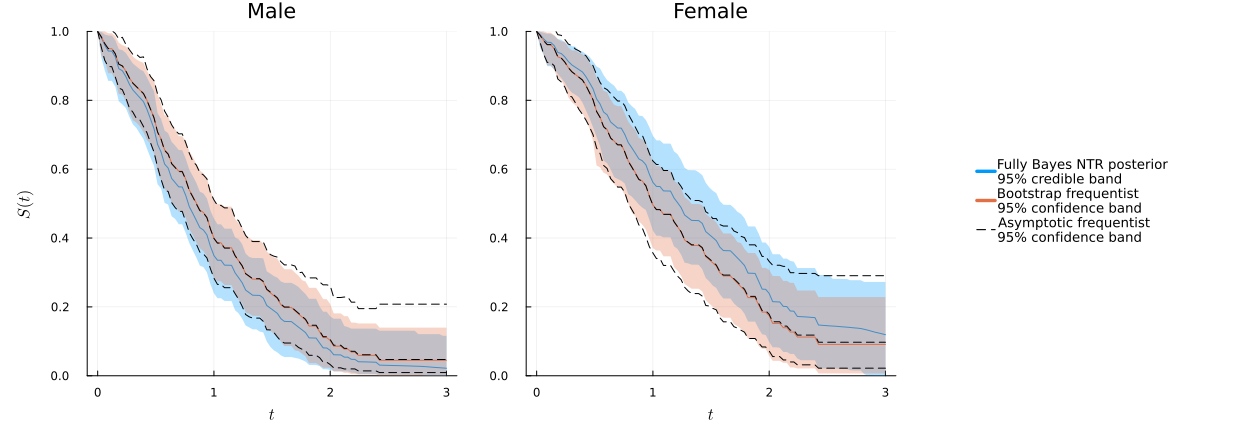

In [38]:
# Plot comparisson of fully Bayesian and frequentist bands for male median covariate.
Mplot = plot(t, fullyBayesNTR_bands[1][2],  ribbon = ( fullyBayesNTR_bands[1][2] .- fullyBayesNTR_bands[1][1], fullyBayesNTR_bands[1][3] .- fullyBayesNTR_bands[1][2]), xlabel="\$t\$", ylabel="\$S(t)\$", fillalpha=0.3, label="NTR posterior 95% credible band",title="Male",size=(600,400))
plot!(t, boot_bands[1][2],  ribbon = (boot_bands[1][2] .- boot_bands[1][1], boot_bands[1][3] .- boot_bands[1][2]), fillalpha=0.3,  label="Bootstrap frequentist 95% confidence band")
plot!(t, freq_bands[1][1],  c=:black, linestyle=:dash,  label="Asymptotic frequentist 95% confidence band")
plot!(t, freq_bands[1][3],  c=:black, linestyle=:dash,  label="")
plot!(t, freq_bands[1][2],  c=:black, linestyle=:dash,  label="",legend=false)
# Plot comparisson of fully Bayesian and frequentist bands for female median covariate.
Fplot = plot(t, fullyBayesNTR_bands[2][2],  ribbon = ( fullyBayesNTR_bands[2][2] .- fullyBayesNTR_bands[2][1], fullyBayesNTR_bands[2][3] .- fullyBayesNTR_bands[2][2]), xlabel="\$t\$", ylabel="\$S(t)\$", fillalpha=0.3, label="NTR posterior \n95% credible band",title="Female",size=(600,400))
plot!(t, boot_bands[2][2],  ribbon = (boot_bands[2][2] .- boot_bands[2][1], boot_bands[2][3] .- boot_bands[2][2]), fillalpha=0.3,  label="Bootstrap frequentist \n95% confidence band")
plot!(t, freq_bands[2][1],  c=:black, linestyle=:dash,  label="Asymptotic frequentist \n95% confidence band")
plot!(t, freq_bands[2][3],  c=:black, linestyle=:dash,  label="")
plot!(t, freq_bands[2][2],  c=:black, linestyle=:dash,  label="")
# Adjust margins of the two equally sized data panels
plot!(
    Mplot,
    left_margin = 9mm,
    right_margin = 2mm,
    bottom_margin = 6mm,
    top_margin = 3mm,
    ylims = (0.0, 1.0)
)
plot!(
    Fplot,
    ylabel = "",
    left_margin = 3mm,
    right_margin = 2mm,
    bottom_margin = 6mm,
    top_margin = 3mm,
    ylims = (0.0, 1.0),
    legend = false
)
# Separate panel containing only the shared legend
legend_plot = plot(
    [NaN],
    [NaN],
    color = 1,
    linewidth = 3,
    label = "Fully Bayes NTR posterior\n95% credible band",
    framestyle = :none,
    showaxis = false,
    grid = false,
    legend = :left,
    legendfontsize = 9,
    background_color_legend = :transparent,
    foreground_color_legend = :transparent
)
plot!(
    legend_plot,
    [NaN],
    [NaN],
    color = 2,
    linewidth = 3,
    label = "Bootstrap frequentist\n95% confidence band"
)
plot!(
    legend_plot,
    [NaN],
    [NaN],
    color = :black,
    linestyle = :dash,
    linewidth = 1,
    label = "Asymptotic frequentist\n95% confidence band"
)
# Equal-sized male and female panels plus a separate legend column
bands_layout = @layout [
    a b c{0.27w}
]
bands_plot = plot(
    Mplot,
    Fplot,
    legend_plot,
    layout = bands_layout,
    size = (1250, 430),
    margin = 1mm,
    link = :y
)
bands_plot

In [39]:
savefig(bands_plot, "lung_cox_uq_BayesVsFreq.png")

"/home/alan/NTRsurv.jl/lung_cox_uq_BayesVsFreq.png"

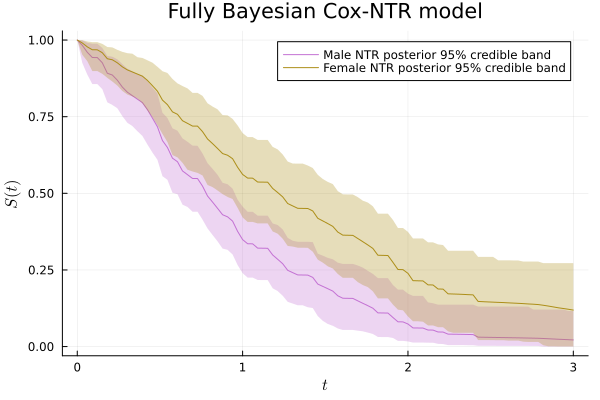

In [40]:
# Plot comparisson of male and female median covariate survival fits with fully Bayesian model.
plot(t, fullyBayesNTR_bands[1][2],  ribbon = ( fullyBayesNTR_bands[1][2] .- fullyBayesNTR_bands[1][1], fullyBayesNTR_bands[1][3] .- fullyBayesNTR_bands[1][2]), c=4, xlabel="\$t\$", ylabel="\$S(t)\$", fillalpha=0.3, label="Male NTR posterior 95% credible band ", title="Fully Bayesian Cox-NTR model", size=(600,400))
plot!(t, fullyBayesNTR_bands[2][2],  ribbon = ( fullyBayesNTR_bands[2][2] .- fullyBayesNTR_bands[2][1], fullyBayesNTR_bands[2][3] .- fullyBayesNTR_bands[2][2]), c=5, fillalpha=0.3,  label="Female NTR posterior 95% credible band")

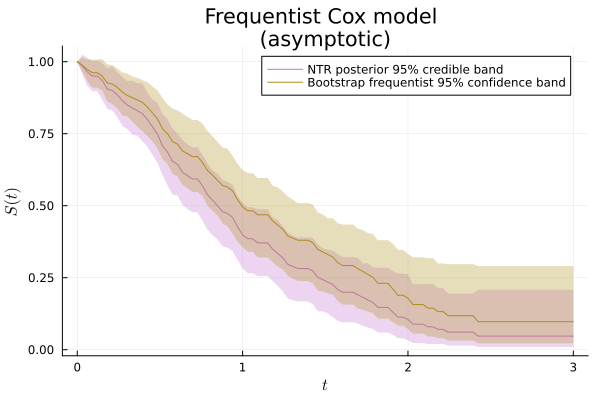

In [41]:
# Plot comparisson of male and female median covariate survival fits with frequentist Cox model (Breslow estimators) \nand asymptotic distribution uncertianty quantification
plot(t, freq_bands[1][2],  ribbon = ( freq_bands[1][2] .- freq_bands[1][1], freq_bands[1][3] .- freq_bands[1][2]), c=4, xlabel="\$t\$", ylabel="\$S(t)\$", fillalpha=0.3, title="Frequentist Cox model \n(asymptotic)", label="NTR posterior 95% credible band",size=(600,400))
plot!(t, freq_bands[2][2],  ribbon = ( freq_bands[2][2] .- freq_bands[2][1], freq_bands[2][3] .- freq_bands[2][2]), c=5, fillalpha=0.3,  label="Bootstrap frequentist 95% confidence band")

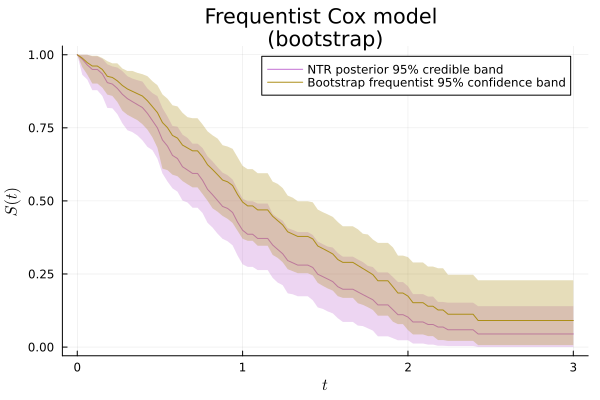

In [42]:
# Plot comparisson of male and female median covariate survival fits with frequentist Cox model (Breslow estimators) \nand bootstrap uncertianty quantification
plot(t, boot_bands[1][2],  ribbon = ( boot_bands[1][2] .- boot_bands[1][1], boot_bands[1][3] .- boot_bands[1][2]), c=4, xlabel="\$t\$", ylabel="\$S(t)\$", fillalpha=0.3, title="Frequentist Cox model \n(bootstrap)", label="NTR posterior 95% credible band",size=(600,400))
plot!(t, boot_bands[2][2],  ribbon = ( boot_bands[2][2] .- boot_bands[2][1], boot_bands[2][3] .- boot_bands[2][2]), c=5, fillalpha=0.3,  label="Bootstrap frequentist 95% confidence band")

We observe that the fully Bayesian Cox-NTR and frequentist Cox-Breslow analyses produce survival bands of broadly comparable width for the representative covariate profiles. The asymptotic and bootstrap Cox procedures agree closely with each other, however they do not overlap signalling a finite data regime also pointed out by their difference with the Bayesian Cox-NTR model in view of the Bernstein-von Mises theorem as discussed in the Weibulls simulation study tutorial.

We compute restricted mean survival times (RMST) up to time $3$ as

$$
\Delta_3
=
\int_0^3
\left\{
S(t\mid\pmb z_{\mathrm F})
-
S(t\mid\pmb z_{\mathrm M})
\right\}
\,\mathrm{d}t,
$$
in order to evaluate differences between the fitted models and perform a sensitivity analysis of the fully Bayesian Cox-NTR model.

In [43]:
# Auxiliary function for RMST computation from a matrix of survival draws
function rmst_draws(t::Vector{Float64}, S::Matrix{Float64})
    return [ trapz(t, S[i, :]) for i in axes(S, 1) ]
end

rmst_draws (generic function with 1 method)

In [44]:
# Three-year RMST differences:
# representative female profile minus representative male profile
SfullyBayesdraws = sample_posterior_survival(t,zv,fully_bayes_cox_model)
Sfreqdraws = freq_asymptotic_draws( 3000, t, zv,  freq_cox_model)
Sbootdraws = bootstrap_survival( 3000, t, zv, df, z_keys)
Δ_NTR = rmst_draws(t, SfullyBayesdraws[2]) .- rmst_draws(t, SfullyBayesdraws[1])
Δ_GP = rmst_draws(t, Sfreqdraws[2]) .- rmst_draws(t, Sfreqdraws[1])
Δ_boot = rmst_draws(t, Sbootdraws[2]) .- rmst_draws(t, Sbootdraws[1]);

In [45]:
# RMST differences between models data frame
function rmst_difference_summary(method::String, Δ::Vector{Float64})
    q = quantile(Δ, [0.025, 0.50, 0.975])
    return (
        method = method,
        mean = mean(Δ),
        standard_deviation = std(Δ),
        median = q[2],
        lower_95 = q[1],
        upper_95 = q[3],
        interval_width = q[3] - q[1],
        fraction_positive = mean(Δ .> 0.0)
    )
end
rmst_summary = DataFrame([
    rmst_difference_summary(
        "Fully Bayesian Cox-NTR",
        Δ_NTR
    ),
    rmst_difference_summary(
        "Asymptotic Cox-Breslow",
        Δ_GP
    ),
    rmst_difference_summary(
        "Bootstrap Cox-Breslow",
        Δ_boot
    )
])
show(stdout, MIME("text/html"), rmst_summary, eltypes=false)

Row,method,mean,standard_deviation,median,lower_95,upper_95,interval_width,fraction_positive
1,Fully Bayesian Cox-NTR,0.446505,0.137187,0.445752,0.185109,0.710538,0.525429,0.999667
2,Asymptotic Cox-Breslow,0.199101,0.129766,0.194195,-0.0464156,0.462676,0.509092,0.943667
3,Bootstrap Cox-Breslow,0.197351,0.125498,0.195526,-0.0492061,0.440644,0.48985,0.942667


In [61]:
function export_rmst_latex(
    rmst_summary::DataFrame;
    latex_path::String = "rmst_summary_tabular.tex"
)
    format4(x) = @sprintf("%.4f", x)

    # Presentation table. The canonical rmst_summary remains numeric.
    rmst_table = DataFrame(
        "Method" => rmst_summary.method,
        "Mean" => format4.(rmst_summary.mean),
        "SD" => format4.(rmst_summary.standard_deviation),
        "Median" => format4.(rmst_summary.median),
        "2.5%" => format4.(rmst_summary.lower_95),
        "97.5%" => format4.(rmst_summary.upper_95),
        #"Interval width" => format4.(rmst_summary.interval_width),
        "Positive fraction" => format4.(rmst_summary.fraction_positive)
    )

    column_labels = names(rmst_table)
    table_body = Matrix(rmst_table)

    open(latex_path, "w") do io
        pretty_table(
            io,
            table_body;
            backend = :latex,
            column_labels = column_labels,
            table_format = latex_table_format__booktabs
        )
    end
    return rmst_table
end

export_rmst_latex (generic function with 1 method)

In [62]:
rmst_table = export_rmst_latex(
    rmst_summary;
    latex_path = "results/rmst_summary_tabular.tex"
)

Row,Method,Mean,SD,Median,2.5%,97.5%,Positive fraction
,String,String,String,String,String,String,String
1,Fully Bayesian Cox-NTR,0.4465,0.1372,0.4458,0.1851,0.7105,0.9997
2,Asymptotic Cox-Breslow,0.1991,0.1298,0.1942,-0.0464,0.4627,0.9437
3,Bootstrap Cox-Breslow,0.1974,0.1255,0.1955,-0.0492,0.4406,0.9427


We observe that the principal difference between the Bayesian and frequentist analyses is not the dispersion of the three-year RMST, but its center. For the representative female-minus-male profile contrast, the fully Bayesian Cox-NTR posterior is centered at a larger positive value than the asymptotic and bootstrap Cox-Breslow distributions. Its posterior standard deviation is nevertheless almost identical to that of the asymptotic Cox approximation. Under the fully Bayesian Cox-NTR model, the 95% credible interval for the contrast excludes zero and the posterior probability that $\Delta_3>0$ is approximately $0.998$. By comparison, the asymptotic and bootstrap Cox-Breslow 95% confidence intervals include zero.

In [47]:
# Cox-NTR model parameters for sensitivity analysis
α_vec = [ 1.0, 5.0 ] 
σ_vec = [ 5.0, 10.0 ] 
λ_vec = [ 0.1, 1.0, 10.0 ]

3-element Vector{Float64}:
  0.1
  1.0
 10.0

In [76]:
# RMST based sensitivity analysis for fullly Bayes Cox-NTR models
function NTRsensitivity_analysis(α_vec::Vector{Float64},σ_vec::Vector{Float64},λ_vec::Vector{Float64},
    t::Vector{Float64},z_news::Vector{Vector{Float64}})
    alphas = zeros(12)
    lambdas = zeros(12)
    sigmas = zeros(12)
    acc_rates = zeros(12)
    Δ_means = zeros(12)
    Δ_sdevs = zeros(12)
    Δ_lowers95percint = zeros(12)
    Δ_uppers95percint = zeros(12)
    Δ_medians = zeros(12)
    Δ_95percint_lengths = zeros(12)
    Δ_probgeqzeros = zeros(12)
    i_tmp = 1
    for α in α_vec, σ in σ_vec, λ in λ_vec
        alphas[i_tmp] = α
        lambdas[i_tmp] = λ
        sigmas[i_tmp] = σ
        baseline_tmp = ExponentialBaseline(λ)
        sd_prop_tuned_tmp, s₀_tune_tmp, lliks₀_tune_tmp = robbins_monro_mh_within_gibbs_tune(150,100,x->NTRsurv.loglikelihood(x,α,baseline_tmp,dataregre) + logpdf(Normal(0,σ),x[1]) + logpdf(Normal(0,σ),x[2]) + logpdf(Normal(0,σ),x[3]),[1.0,1.0,1.0],[1.0,1.0,1.0],[0.4,0.4,0.4],0.7)
        chain_s_tmp, _ =  random_walk_mh_within_gibbs( 3000, x-> NTRsurv.loglikelihood(x,α,baseline_tmp,dataregre) + logpdf(Normal(0,σ),x[1]) + logpdf(Normal(0,σ),x[2]) + logpdf(Normal(0,σ),x[3]), s₀_tune_tmp, lliks₀_tune_tmp, sd_prop_tuned_tmp[end])
        acc_rates[i_tmp] = mean( acceptance_rate(chain_s) )
        fully_bayes_cox_model_tmp = CoxNeutralToTheRightFullyBayesianModel(chain_s, α, baseline, dataregre)
        Sdraws_tmp = sample_posterior_survival(t, z_news, fully_bayes_cox_model_tmp)
        Δ_tmp = rmst_draws(t, Sdraws_tmp[2]) .- rmst_draws(t, Sdraws_tmp[1])
        Δ_means[i_tmp] = mean(Δ_tmp)
        Δ_sdevs[i_tmp] = std(Δ_tmp)
        q_tmp = quantile(Δ_tmp,[0.025,0.5,0.975])
        Δ_lowers95percint[i_tmp] = q_tmp[1]
        Δ_uppers95percint[i_tmp] = q_tmp[3]
        Δ_medians[i_tmp] = q_tmp[2]
        Δ_95percint_lengths[i_tmp] = q_tmp[3]-q_tmp[1]
        Δ_probgeqzeros[i_tmp] = mean( Δ_tmp .> 0.0 )
        i_tmp += 1
    end
    return alphas, lambdas, sigmas, acc_rates, Δ_means, Δ_sdevs, Δ_lowers95percint, Δ_uppers95percint, Δ_medians, Δ_95percint_lengths, Δ_probgeqzeros
end

NTRsensitivity_analysis (generic function with 1 method)

In [77]:
# Sensitivity analysis
alphas, lambdas, sigmas, sens_acc_rates, sens_Δ_means, sens_Δ_sdevs, sens_Δ_lower95percints, sens_Δ_upper95percints, sens_Δ_medians, sens_Δ_95percint_lengths, sens_Δ_probgeqzeros = NTRsensitivity_analysis(α_vec,σ_vec,λ_vec,t,zv)

Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12


([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0], [0.1, 1.0, 10.0, 0.1, 1.0, 10.0, 0.1, 1.0, 10.0, 0.1, 1.0, 10.0], [5.0, 5.0, 5.0, 10.0, 10.0, 10.0, 5.0, 5.0, 5.0, 10.0, 10.0, 10.0], [0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651], [0.4461214019986013, 0.4458706512244638, 0.4461071457493973, 0.4462049852541036, 0.44548234502685863, 0.4458539367147774, 0.45178563089605434, 0.4524204595877922, 0.45093281544423536, 0.45213979009991606, 0.4521318871058138, 0.45221412658397914], [0.13715037941876018, 0.13715607649211292, 0.13621120344006088, 0.13698312319642944, 0.13568164186612214, 0.13683153709788473, 0.13913779956270167, 0.140487007612691, 0.13900006850251148, 0.140329014770765, 0.14009779017496227, 0.14028283308203668], [0.18484636877318836, 0.18319467592230881, 0.17703216079917064, 0.1780503946

In [92]:
sens_Δ_probgeqzeros

12-element Vector{Float64}:
 0.9996666666666667
 0.9996666666666667
 0.9996666666666667
 0.9996666666666667
 0.9996666666666667
 0.9996666666666667
 0.9996666666666667
 0.9996666666666667
 0.9996666666666667
 0.9996666666666667
 0.9996666666666667
 0.9996666666666667

In [93]:
# Sensitivity analysis data frame
sensdf = DataFrame( alpha = alphas, lambda=lambdas, sigma = sigmas, Acc_rates =  sens_acc_rates, Δ_mean = round.(sens_Δ_means; digits = 3), 
    Δ_stdev = round.(sens_Δ_sdevs; digits = 3), Δ_95percCIlower = round.( sens_Δ_lower95percints; digits=3), 
    Δ_95percCIupper = round.( sens_Δ_upper95percints; digits=3), Δ_median = round.( sens_Δ_medians; digits=3),
    Δ_probgeqzero = sens_Δ_probgeqzeros )
show(stdout, MIME("text/html"), sensdf, eltypes=false)

Row,alpha,lambda,sigma,Acc_rates,Δ_mean,Δ_stdev,Δ_95percCIlower,Δ_95percCIupper,Δ_median,Δ_probgeqzero
1,1.0,0.1,5.0,0.397244,0.446,0.137,0.185,0.714,0.444,0.999667
2,1.0,1.0,5.0,0.397244,0.446,0.137,0.183,0.708,0.445,0.999667
3,1.0,10.0,5.0,0.397244,0.446,0.136,0.177,0.708,0.447,0.999667
4,1.0,0.1,10.0,0.397244,0.446,0.137,0.178,0.713,0.445,0.999667
5,1.0,1.0,10.0,0.397244,0.445,0.136,0.182,0.706,0.444,0.999667
6,1.0,10.0,10.0,0.397244,0.446,0.137,0.183,0.712,0.445,0.999667
7,5.0,0.1,5.0,0.397244,0.452,0.139,0.188,0.716,0.448,0.999667
8,5.0,1.0,5.0,0.397244,0.452,0.14,0.182,0.722,0.451,0.999667
9,5.0,10.0,5.0,0.397244,0.451,0.139,0.186,0.719,0.449,0.999667
10,5.0,0.1,10.0,0.397244,0.452,0.14,0.185,0.721,0.45,0.999667


In [94]:
function export_ntr_sensitivity_latex( sensdf::DataFrame; latex_path::String = "results/cox_ntr_sensitivity_tabular.tex")
    mkpath(dirname(latex_path))
    open(latex_path, "w") do io
        println(
            io,
            "\\begin{tabular*}{\\textwidth}" *
            "{@{\\extracolsep{\\fill}}ccc rrrcr@{}}"
        )
        println(io, "\\toprule")
        println(
            io,
            "\$\\alpha\$ & " *
            "\$\\lambda\$ & " *
            "\$\\sigma\$ & " *
            "Mean & " *
            "SD & " *
            "Median & " *
            "95\\% CrI & " *
            "\$\\Pr(\\Delta_3>0\\mid\\mathcal D_n)\$ \\\\"
        )
        println(io, "\\midrule")
        for row in eachrow(sensdf)
            table_row = @sprintf(
                "%.0f & %.1f & %.0f & %.3f & %.3f & %.3f & (%.3f, %.3f) & %.4f",
                row.alpha,
                row.lambda,
                row.sigma,
                row.Δ_mean,
                row.Δ_stdev,
                row.Δ_median,
                row.Δ_95percCIlower,
                row.Δ_95percCIupper,
                row.Δ_probgeqzero
            )
            # Add the LaTeX row ending "\\" followed by a newline.
            println(io, table_row, " \\\\")
        end
        println(io, "\\bottomrule")
        println(io, "\\end{tabular*}")
    end
    return latex_path
end

export_ntr_sensitivity_latex (generic function with 1 method)

In [95]:
names(sensdf)

10-element Vector{String}:
 "alpha"
 "lambda"
 "sigma"
 "Acc_rates"
 "Δ_mean"
 "Δ_stdev"
 "Δ_95percCIlower"
 "Δ_95percCIupper"
 "Δ_median"
 "Δ_probgeqzero"

In [96]:
sensitivity_latex_path = export_ntr_sensitivity_latex(
    sensdf;
    latex_path = "results/cox_ntr_sensitivity_tabular.tex"
)

"results/cox_ntr_sensitivity_tabular.tex"

Sensitivity analyses using alternative baseline and coefficient-prior specifications produced qualitatively similar Cox-NTR conclusion that the posterior distribution of the three-year RMST contrast is concentrated primarily on positive values. However there is moderate sensitivity in the estimated magnitudes.